In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import os

In [2]:
testImage = cv2.imread('TB_Chest_Radiography_Database/Tuberculosis/Tuberculosis-126.png')

In [3]:
testImage

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        ...,
        [0, 0, 0],
        [1, 1, 1],
        [1, 1, 1]],

       [[0, 0, 0],
        [0, 0, 0],
        [1, 1, 1],
        ...,
        [1, 1, 1],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [1, 1, 1],
        ...,
        [1, 1, 1],
        [0, 0, 0],
        [0, 0, 0]]], shape=(512, 512, 3), dtype=uint8)

In [4]:
print("Min pixel value:", testImage.min())
print("Max pixel value:", testImage.max())

Min pixel value: 0
Max pixel value: 233


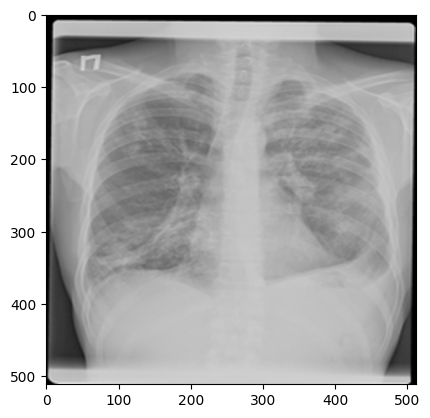

In [5]:
plt.imshow(testImage)

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
labels = {
    "Normal":0, 
    "Tuberculosis":1
}

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    channel_shift_range=0.05,
    fill_mode='nearest'
)

In [8]:
base_path = 'TB_Chest_Radiography_Database'
target_count = 3500

X = []
y = []

for class_name in os.listdir(base_path):
    if class_name not in labels:
        continue

    class_path = os.path.join(base_path, class_name)
    files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    n_files = len(files)

    if n_files == 0:
        continue

    repeat_times = target_count // n_files
    extra = target_count % n_files

    for idx, img_file in enumerate(files):
        img_path = os.path.join(class_path, img_file)
        image = cv2.imread(img_path)
        
        if image is None:
            continue
            
        image = cv2.resize(image, (224, 224))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        image = (image / 255.0).astype(np.float32)

        label = labels[class_name]

        X.append(image)
        y.append(label)

        for _ in range(repeat_times - 1):
            image_exp = np.expand_dims(image, 0)
            aug_image = next(datagen.flow(image_exp, batch_size=1))[0].astype(np.float32)
            
            X.append(aug_image)
            y.append(label)

        if idx < extra:
            image_exp = np.expand_dims(image, 0)
            aug_image = next(datagen.flow(image_exp, batch_size=1))[0].astype(np.float32)
            
            X.append(aug_image)
            y.append(label)

X = np.array(X)
y = np.array(y)

In [9]:
X.shape

(7000, 224, 224, 3)

In [10]:
y.shape

(7000,)

In [11]:
from keras.utils import to_categorical

In [12]:
y = to_categorical(y, num_classes=2)

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train.shape

(5600, 224, 224, 3)

In [16]:
y_train.shape

(5600, 2)

In [17]:
X_test.shape

(1400, 224, 224, 3)

In [18]:
y_test.shape

(1400, 2)

In [19]:
from keras.applications import MobileNetV2

In [20]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [21]:
from keras.models import Model
from keras.layers import Dense, Flatten, Input, GlobalAveragePooling2D, Dropout
from keras.optimizers import Adam

In [22]:
for layer in base_model.layers:
    layer.trainable = False

In [23]:
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 18,355,842 (70.02 MB)

 Trainable params: 16,097,858 (61.41 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [24]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [25]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.9668 - loss: 0.4161 - val_accuracy: 0.9950 - val_loss: 0.0285
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9871 - loss: 0.0778 - val_accuracy: 0.9957 - val_loss: 0.0186
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 176s 995ms/step - accuracy: 0.9898 - loss: 0.0545 - val_accuracy: 0.9914 - val_loss: 0.0413
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.9948 - loss: 0.0255 - val_accuracy: 0.9964 - val_loss: 0.0182
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.9948 - loss: 0.0251 - val_accuracy: 0.9971 - val_loss: 0.0245
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 197s 976ms/step - accuracy: 0.9925 - loss: 0.0332 - val_accuracy: 0.9957 - val_loss: 0.0344
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.9945 - loss: 0.0212 - val_accuracy: 0.9971 - val_loss: 0.0180
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.9920 - loss: 0.0416 - va

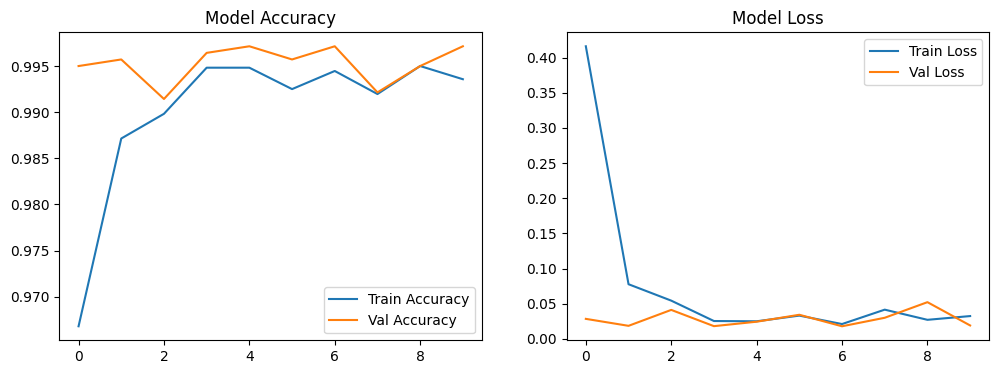

In [26]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(model.history.history['accuracy'], label='Train Accuracy')
plt.plot(model.history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(model.history.history['loss'], label='Train Loss')
plt.plot(model.history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

In [27]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

44/44 ━━━━━━━━━━━━━━━━━━━━ 31s 702ms/step - accuracy: 0.9971 - loss: 0.0192
Test accuracy: 0.9971428513526917
Test loss: 0.019163286313414574


In [73]:
X_clean = []
y_clean = []

for i in os.listdir('TB_Chest_Radiography_Database/'):
    for j in os.listdir(f'TB_Chest_Radiography_Database/{i}')[:500]:
        try:
            image = cv2.imread(f'TB_Chest_Radiography_Database/{i}/{j}')
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (224, 224))
            image = image / 255.0

            X_clean.append(image)
            y_clean.append(labels[i])
        except:
            print(j)

X_clean = np.array(X_clean)
y_clean = np.array(y_clean)

In [74]:
X_clean.shape

(1000, 224, 224, 3)

32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 772ms/step


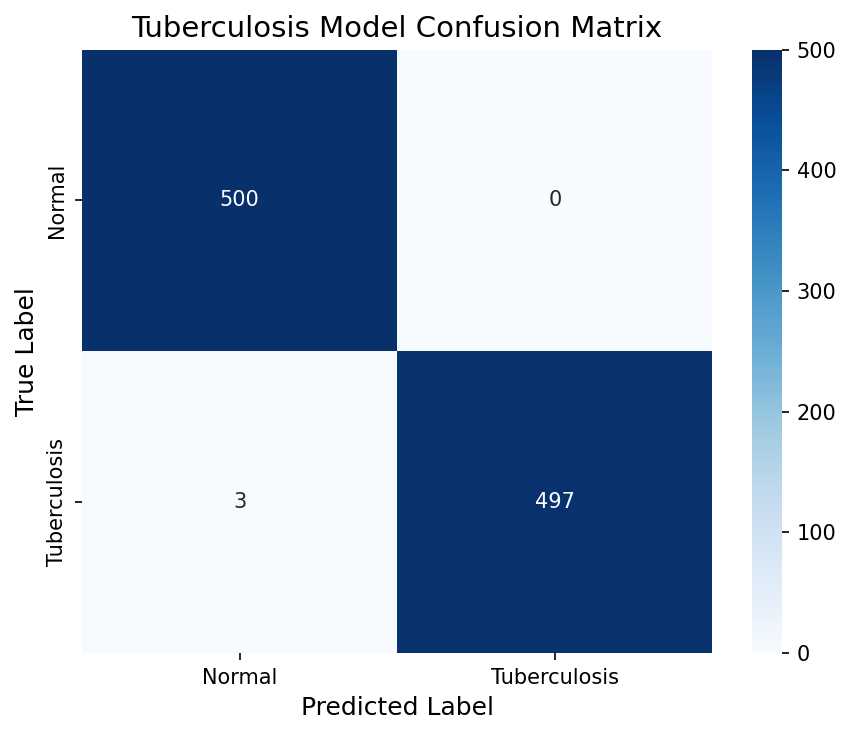

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00       500
Tuberculosis       1.00      0.99      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [75]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(X_clean, batch_size=32)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = y_clean.copy()
if y_true.min() == 1:
    y_true = y_true - 1

cm = confusion_matrix(y_true, y_pred)
class_names = ['Normal', 'Tuberculosis']

plt.figure(figsize=(6, 5), dpi = 150)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title('Tuberculosis Model Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
# plt.savefig('Tuberculosis_Model_Confusion_Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [76]:
import pickle

In [77]:
with open('FinalTuberculosisModel.pkl', 'wb') as file:
    pickle.dump(model, file)

In [78]:
index_to_char = {
    0 : "Normal", 
    1 : "Tuberculosis"
}

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import os
import pickle
import tensorflow as tf
from tensorflow import keras

In [4]:
with open('FinalTuberculosisModel.pkl', 'rb') as file:
    model = pickle.load(file)

In [97]:
def make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name,
    pred_index=None
):
    grad_model = tf.keras.models.clone_model(model)
    grad_model.set_weights(model.get_weights())

    if hasattr(grad_model.layers[-1], "activation"):
        grad_model.layers[-1].activation = tf.keras.activations.linear

    grad_model = tf.keras.models.Model(
        inputs=grad_model.inputs,
        outputs=[
            grad_model.get_layer(last_conv_layer_name).output,
            grad_model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        score = predictions[:, pred_index]

    gradients = tape.gradient(score, conv_output)

    if gradients is None or tf.reduce_max(tf.abs(gradients)) == 0:
        heatmap = tf.reduce_mean(conv_output[0], axis=-1)
    else:
        weights = tf.reduce_mean(
            gradients,
            axis=(0, 1, 2)
        )

        conv_output = conv_output[0]

        heatmap = conv_output @ weights[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return heatmap.numpy()

In [98]:
def generate_sharp_overlay(
    img_224_bgr: np.ndarray,
    heatmap_raw: np.ndarray,
    threshold: float = 0.30,
    max_alpha: float = 0.65,
    margin_pixels: int = 12
) -> np.ndarray:

    if heatmap_raw.shape[:2] != (224, 224):
        heatmap = cv2.resize(
            heatmap_raw,
            (224, 224),
            interpolation=cv2.INTER_CUBIC
        )
    else:
        heatmap = heatmap_raw.copy()

    max_value = heatmap.max()

    if max_value <= 1e-8:
        return img_224_bgr

    heatmap = heatmap / max_value

    heatmap = np.where(
        heatmap >= threshold,
        heatmap,
        0
    ).astype(np.float32)

    if margin_pixels > 0:
        heatmap[:margin_pixels, :] = 0
        heatmap[-margin_pixels:, :] = 0
        heatmap[:, :margin_pixels] = 0
        heatmap[:, -margin_pixels:] = 0

    heatmap_image = np.uint8(heatmap * 255)
    heatmap_image = cv2.applyColorMap(
        heatmap_image,
        cv2.COLORMAP_TURBO
    )

    alpha = (heatmap * max_alpha)[:, :, np.newaxis]

    image = img_224_bgr.astype(np.float32)
    heatmap_image = heatmap_image.astype(np.float32)

    result = image * (1 - alpha) + heatmap_image * alpha

    return np.clip(result, 0, 255).astype(np.uint8)

In [99]:
def diagnose_and_visualize(
    image_path: str,
    model: keras.Model,
    last_conv_layer_name: str,
    class_names: list = ["Normal", "Tuberculosis"],
    disease_class_index: int = 1,
    disease_threshold: float = 0.5
):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224))

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = np.expand_dims(img_rgb / 255.0, axis=0)

    prediction = model.predict(img_tensor, verbose=0)[0]

    if len(prediction) == 1:
        disease_probability = float(prediction[0])
    else:
        disease_probability = float(prediction[disease_class_index])

    has_disease = disease_probability >= disease_threshold

    if has_disease:
        heatmap = make_gradcam_heatmap(
            img_tensor,
            model,
            last_conv_layer_name,
            pred_index=disease_class_index
        )

        overlay = generate_sharp_overlay(
            img,
            heatmap,
            threshold=0.45
        )

        overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
        right_title = "Infection zone (Grad-CAM)\nSuspicious areas"
    else:
        overlay = img_rgb.copy()
        right_title = "No suspicious areas detected"

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=150)

    if has_disease:
        status = f"{class_names[1]} ({disease_probability * 100:.1f}%)"
        title_color = "red"
    else:
        status = f"{class_names[0]} ({(1 - disease_probability) * 100:.1f}%)"
        title_color = "green"

    axes[0].imshow(img_rgb)
    axes[0].set_title(
        f"Original X-ray\nStatus: {status}",
        fontsize=11,
        fontweight="bold",
        color=title_color
    )
    axes[0].axis("off")

    axes[1].imshow(overlay)
    axes[1].set_title(
        right_title,
        fontsize=11,
        fontweight="bold"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

C:\Users\user\Desktop\ML Python\venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


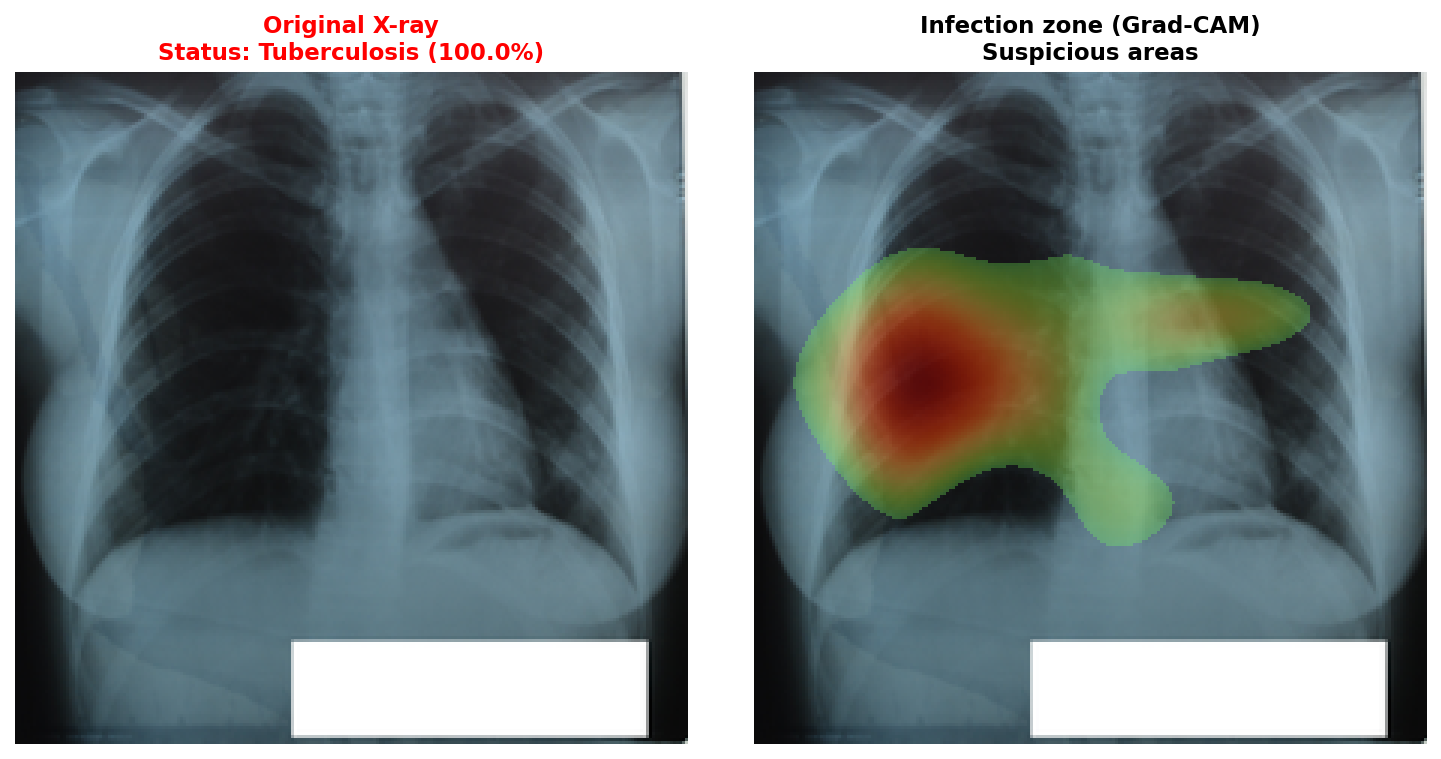

In [100]:
diagnose_and_visualize(
    image_path="TB_Chest_Radiography_Database/Tuberculosis/Tuberculosis-290.png",
    model=model,
    last_conv_layer_name="out_relu",
    disease_threshold=0.5,
)

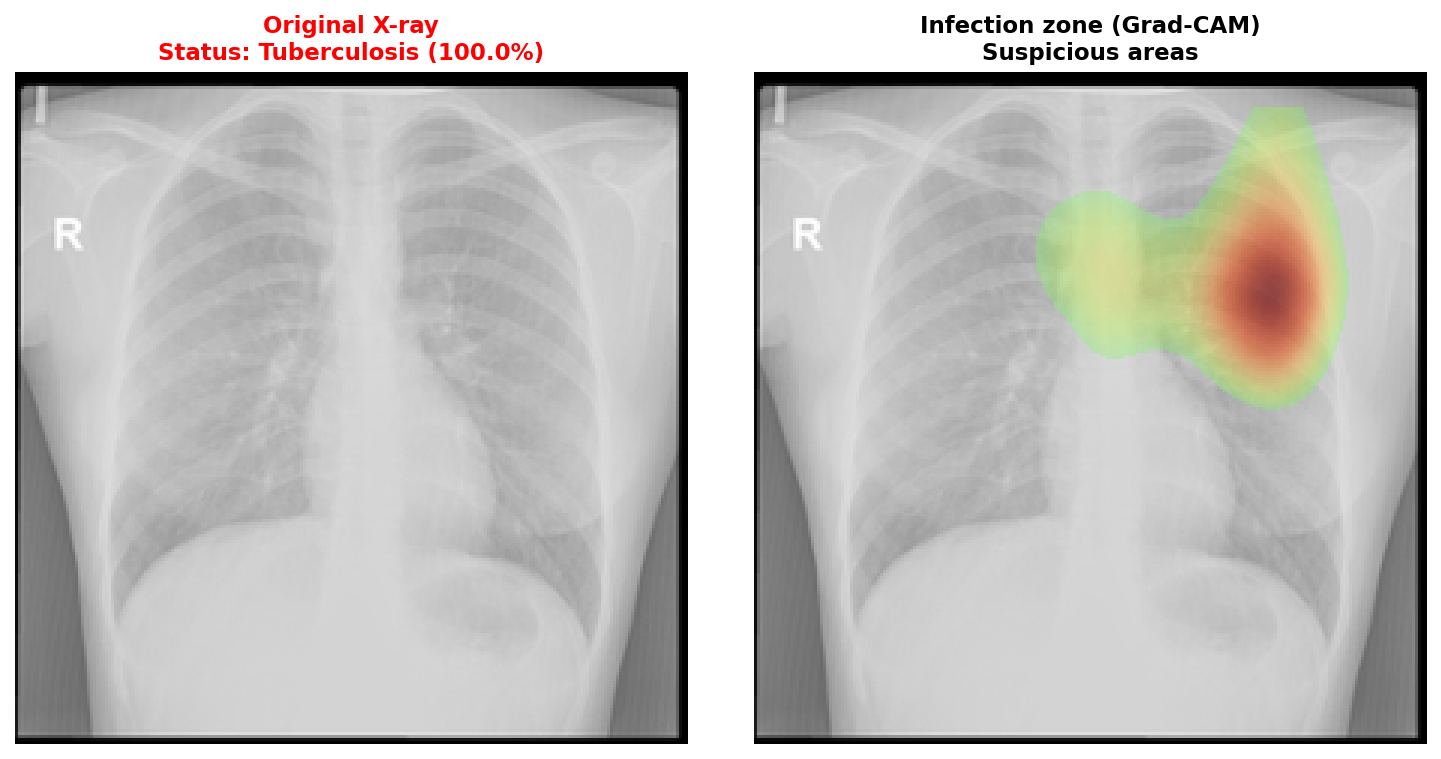

In [101]:
diagnose_and_visualize(
    image_path="TB_Chest_Radiography_Database/Tuberculosis/Tuberculosis-41.png",
    model=model,
    last_conv_layer_name="out_relu",
    disease_threshold=0.5,
)